# 🏨 **Hotel Booking Analytics**

## **Analyse des réservations hôtelières**

### **Objectif**

Ce projet analyse les réservations de deux hôtels :

- Resort Hotel
- City Hotel

L'objectif est de comprendre :

- le volume des réservations ;
- les annulations ;
- le comportement des clients ;
- les canaux de distribution ;
- la saisonnalité ;
- la durée des séjours ;
- la relation entre le délai de réservation et les annulations.

L'analyse combine :

**Python → Data Cleaning → EDA → Feature Engineering → SQL → Apache Superset**

### **Business Questions**

1. Quel est le taux d'annulation global ?
2. Quel hôtel présente le taux d'annulation le plus élevé ?
3. Quels mois enregistrent le plus de réservations ?
4. Quels segments de clients annulent le plus ?
5. Quels canaux génèrent le plus de réservations ?
6. Existe-t-il une relation entre le lead time et les annulations ?
7. Quelle est la durée moyenne des séjours ?
8. Quels segments de clients présentent les comportements les plus intéressants ?

## 1. **Importation des librairies**

In [1]:
# IMPORTATION DES LIBRAIRIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Librairies importées avec succès.")

Librairies importées avec succès.


## 2. **Configuration**

In [2]:
BASE_DIR = Path("..")

DATA_PATH = BASE_DIR / "data" / "hotel_bookings.csv"

OUTPUT_DIR = BASE_DIR / "outputs"

FIGURES_DIR = OUTPUT_DIR / "figures"

CLEANED_DIR = OUTPUT_DIR / "cleaned"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CLEANED_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset :", DATA_PATH)
print("Outputs :", OUTPUT_DIR)

Dataset : ../data/hotel_bookings.csv
Outputs : ../outputs


## 3. **Chargement des données**

In [6]:
df = pd.read_csv(DATA_PATH)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
df.shape

(119390, 32)

## 4. **Comprehension des données**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


In [10]:
# NOMBRE DE VALEURS UNIQUES

unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [
        df[col].nunique()
        for col in df.columns
    ]
})

display(unique_values)

,Column,Unique Values
0,hotel,2
1,is_canceled,2
2,lead_time,479
3,arrival_date_year,3
4,arrival_date_month,12
5,arrival_date_week_number,53
6,arrival_date_day_of_month,31
7,stays_in_weekend_nights,17
8,stays_in_week_nights,35
9,adults,14


## 5. **Data Quality**

In [11]:
# VALEURS MANQUANTES

missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": (
        df.isna().mean() * 100
    ).round(2)
})

missing = (
    missing
    .sort_values("Missing %", ascending=False)
)

display(missing[missing["Missing Values"] > 0])

,Missing Values,Missing %
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [12]:
# VALEURS MANQUANTES

missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": (
        df.isna().mean() * 100
    ).round(2)
})

missing = (
    missing
    .sort_values("Missing %", ascending=False)
)

display(missing[missing["Missing Values"] > 0])

,Missing Values,Missing %
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [14]:
## DOUBLONS
duplicate_count = df.duplicated().sum()

print(f"Nombre de doublons : {duplicate_count:,}")

Nombre de doublons : 31,994


## 6. **Analyse des variables importantes**

In [20]:
# VALEURS DES VARIABLES CATÉGORIELLES
categorical_columns = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "customer_type",
    "deposit_type",
    "reservation_status"
]

for col in categorical_columns:
    print("\n" + "=" * 30)
    print(col.upper())
    print("=" * 30)
    print(df[col].value_counts(dropna=False))


HOTEL
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

MEAL
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

MARKET_SEGMENT
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

DISTRIBUTION_CHANNEL
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

CUSTOMER_TYPE
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

DEPOSIT_TYPE
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

RESERVATION_STATUS
reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, 

## 7. **Nettoyage**

In [21]:
# COPIE DU DATASET
hotel = df.copy()

In [23]:
# TRAITEMENT DE CHILDREN
print("Valeurs manquantes avant :",hotel["children"].isna().sum())

hotel["children"] = hotel["children"].fillna(0)

print("Valeurs manquantes après :",hotel["children"].isna().sum())

Valeurs manquantes avant : 0
Valeurs manquantes après : 0


In [24]:
# COUNTRY
print("Pays manquants :",hotel["country"].isna().sum())

hotel["country"] = hotel["country"].fillna("Unknown")

Pays manquants : 488


Pour `country`, **ne remplace pas automatiquement par un pays**.

In [25]:
# TRAITEMENT DES VARIABLES CATÉGORIELLES

hotel["country"] = hotel["country"].fillna("Unknown")

hotel["agent"] = hotel["agent"].fillna(0)

hotel["company"] = hotel["company"].fillna(0)

print("Valeurs manquantes restantes :")

display(
    hotel.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Valeurs manquantes restantes :


hotel                          0
is_canceled                    0
reservation_status             0
total_of_special_requests      0
required_car_parking_spaces    0
adr                            0
customer_type                  0
days_in_waiting_list           0
company                        0
agent                          0
dtype: int64

## 8. **Suppression des doublons**

In [26]:
# SUPPRESSION DES DOUBLONS
before = len(hotel)

hotel = hotel.drop_duplicates()

after = len(hotel)

print(f"Lignes avant : {before:,}")
print(f"Lignes après : {after:,}")
print(f"Doublons supprimés : {before - after:,}")

Lignes avant : 119,390
Lignes après : 87,396
Doublons supprimés : 31,994


## 9. Feature Engineering


In [27]:
# DATE D'ARRIVÉE
hotel["arrival_date"] = pd.to_datetime(
    hotel[["arrival_date_year", "arrival_date_month","arrival_date_day_of_month"]].astype(str).agg("-".join, axis=1),
    errors="coerce")

In [28]:
hotel["arrival_year"] = hotel["arrival_date"].dt.year

hotel["arrival_month_num"] = hotel["arrival_date"].dt.month

hotel["arrival_day"] = hotel["arrival_date"].dt.day

## 10. **Total Guests**

In [30]:
# TOTAL GUESTS

hotel["total_guests"] = (hotel["adults"] + hotel["children"] + hotel["babies"])

display(hotel[["adults","children","babies","total_guests"]].head())

,adults,children,babies,total_guests
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,1,0.0,0,1.0
3,1,0.0,0,1.0
4,2,0.0,0,2.0


## 11. **Total Nights**

In [32]:
# TOTAL NIGHTS

hotel["total_nights"] = (hotel["stays_in_weekend_nights"]+ hotel["stays_in_week_nights"])

## 12. **Lead Time Category**

In [33]:

# LEAD TIME CATEGORY

hotel["lead_time_category"] = pd.cut(hotel["lead_time"],bins=[-1, 30, 90, np.inf],
    labels=["0-30 days","31-90 days",">90 days"])

display(hotel["lead_time_category"]
    .value_counts()
    .sort_index()
)

lead_time_category
0-30 days     34644
31-90 days    22744
>90 days      30008
Name: count, dtype: int64

# 13. **Is Cancelled**

In [35]:
# IS CANCELLED

hotel["is_cancelled"] = (hotel["is_canceled"].astype(bool))

hotel["is_cancelled"].value_counts()

is_cancelled
False    63371
True     24025
Name: count, dtype: int64

## 14. **Average Daily Rate**

In [36]:
# ESTIMATION DU REVENUE
hotel["estimated_revenue"] = (hotel["adr"] *hotel["total_nights"])

hotel[["adr","total_nights","estimated_revenue"]].head()

,adr,total_nights,estimated_revenue
0,0.0,0,0.0
1,0.0,0,0.0
2,75.0,1,75.0
3,75.0,1,75.0
4,98.0,2,196.0


## 15. **Contrôle des incohérences**

In [37]:
# CONTRÔLE DES VALEURS INCOHÉRENTES
print("Réservations avec 0 adulte :",(hotel["adults"] == 0).sum())

print("Réservations avec 0 client :",(hotel["total_guests"] == 0).sum())

print("ADR négatif :",(hotel["adr"] < 0).sum())

print("Lead time négatif :",(hotel["lead_time"] < 0).sum())


Réservations avec 0 adulte : 385
Réservations avec 0 client : 166
ADR négatif : 1
Lead time négatif : 0


In [38]:
hotel[hotel["total_guests"] == 0][["hotel","adults","children","babies","reservation_status"]].head(20)

,hotel,adults,children,babies,reservation_status
2224,Resort Hotel,0,0.0,0,Check-Out
2409,Resort Hotel,0,0.0,0,Check-Out
3181,Resort Hotel,0,0.0,0,Check-Out
3684,Resort Hotel,0,0.0,0,Check-Out
3708,Resort Hotel,0,0.0,0,Check-Out
4127,Resort Hotel,0,0.0,0,Canceled
9376,Resort Hotel,0,0.0,0,Canceled
31765,Resort Hotel,0,0.0,0,Check-Out
32029,Resort Hotel,0,0.0,0,Check-Out
32827,Resort Hotel,0,0.0,0,Check-Out


## 16. **KPI généraux**

In [39]:
# KPI GÉNÉRAUX
total_bookings = len(hotel)

cancelled_bookings = hotel["is_cancelled"].sum()

cancellation_rate = (cancelled_bookings /total_bookings* 100)

average_stay = hotel["total_nights"].mean()

average_lead_time = hotel["lead_time"].mean()

average_adr = hotel["adr"].mean()

total_revenue_estimated = hotel["estimated_revenue"].sum()


In [40]:
print("========== KPI ==========")

print(f"Total bookings : {total_bookings:,.0f}")

print(f"Cancelled bookings : {cancelled_bookings:,.0f}")

print(f"Cancellation rate : {cancellation_rate:.2f}%")

print(f"Average stay : {average_stay:.2f} nights")

print(f"Average lead tim : {average_lead_time:.2f} days")

print(f"Average ADR : {average_adr:.2f}")
print(f"Estimated revenue: "f"{total_revenue_estimated:,.2f}")

========== KPI ==========
Total bookings : 87,396
Cancelled bookings : 24,025
Cancellation rate : 27.49%
Average stay : 3.63 nights
Average lead tim : 79.89 days
Average ADR : 106.34
Estimated revenue: 34,460,939.31


## 17. **Analyse par hôtel**

In [41]:
# KPI PAR HÔTEL

hotel_performance = (hotel.groupby("hotel").agg(
        bookings=("hotel", "size"),
        cancellations=("is_cancelled", "sum"),
        cancellation_rate=("is_cancelled", "mean"),
        avg_stay=("total_nights", "mean"),
        avg_lead_time=("lead_time", "mean"),
        avg_adr=("adr", "mean"),
        estimated_revenue=("estimated_revenue", "sum")
    )
    .reset_index()
)

hotel_performance["cancellation_rate"] *= 100

display(hotel_performance)

,hotel,bookings,cancellations,cancellation_rate,avg_stay,avg_lead_time,avg_adr,estimated_revenue
0,City Hotel,53428,16049,30.038557,3.146609,77.678521,110.985944,18774101.54
1,Resort Hotel,33968,7976,23.480923,4.392016,83.371938,99.025346,15686837.77


## 18. **Réservations par mois**

In [42]:
# RÉSERVATIONS PAR MOIS
monthly_bookings = (hotel.groupby(["arrival_year", "arrival_month_num", "arrival_date_month"],as_index=False)
    .agg(bookings=("hotel", "size"),cancellations=("is_cancelled", "sum"))
    .sort_values(["arrival_year", "arrival_month_num"])
)

monthly_bookings["cancellation_rate"] = (monthly_bookings["cancellations"]/ monthly_bookings["bookings"]* 100)

display(monthly_bookings)

,arrival_year,arrival_month_num,arrival_date_month,bookings,cancellations,cancellation_rate
0,2015,7,July,1674,512,30.585424
1,2015,8,August,2453,571,23.277619
2,2015,9,September,2839,566,19.936597
3,2015,10,October,2700,440,16.296296
4,2015,11,November,1665,243,14.594595
5,2015,12,December,1982,372,18.768920
6,2016,1,January,1849,301,16.279070
7,2016,2,February,2806,528,18.816821
8,2016,3,March,3831,886,23.127121
9,2016,4,April,3770,1014,26.896552


## 19. **Visualisation**

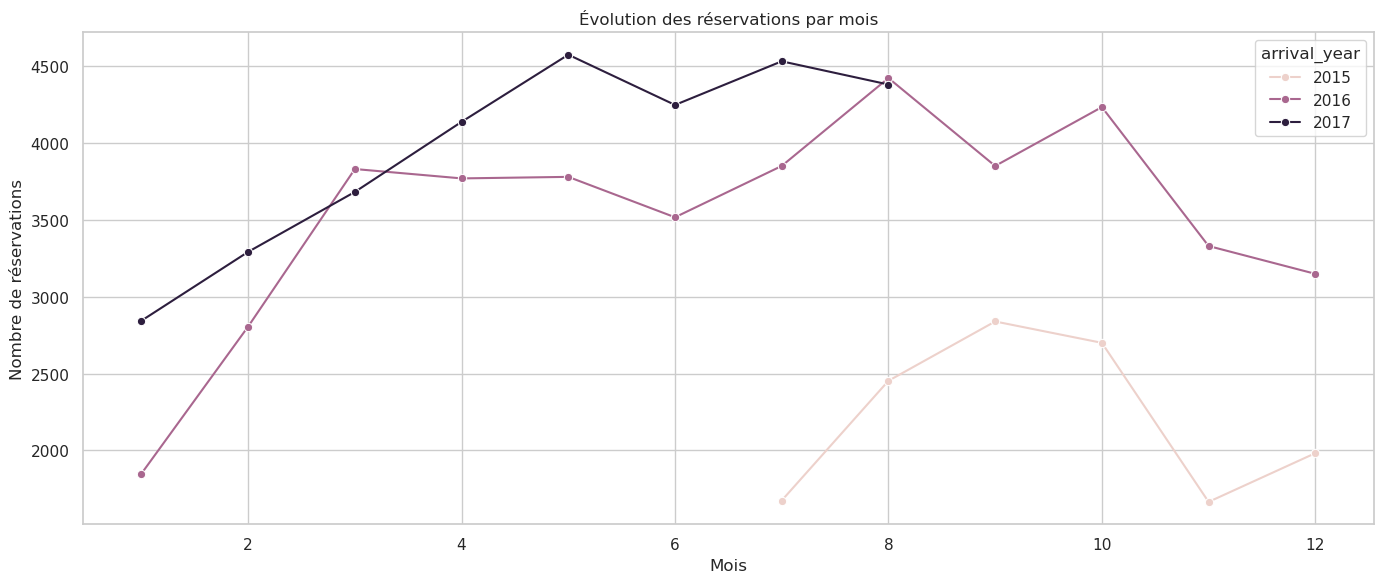

In [44]:
# VISUALISATION — BOOKINGS PAR MOIS
plt.figure(figsize=(14, 6))

sns.lineplot(data=monthly_bookings,
    x="arrival_month_num",
    y="bookings",
    hue="arrival_year",
    marker="o"
)
plt.title("Évolution des réservations par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de réservations")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_bookings.png",dpi=300)
plt.show()

## 20. **Cancellation Rate par hôtel**

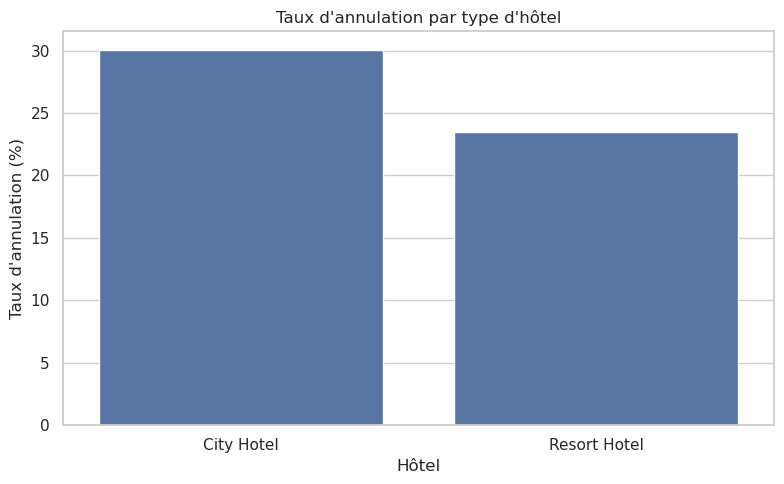

In [45]:
# CANCELLATION RATE PAR HÔTEL

plt.figure(figsize=(8, 5))

sns.barplot(data=hotel_performance,
    x="hotel",
    y="cancellation_rate"
)

plt.title("Taux d'annulation par type d'hôtel")
plt.xlabel("Hôtel")
plt.ylabel("Taux d'annulation (%)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cancellation_rate_hotel.png",dpi=300)
plt.show()

## 21. **Cancellation Rate par Customer Type**

In [46]:
# ANNULATIONS PAR TYPE DE CLIENT

customer_analysis = (hotel.groupby("customer_type")
    .agg(
        bookings=("customer_type", "size"),
        cancellations=("is_cancelled", "sum")
    )
    .reset_index()
)

customer_analysis["cancellation_rate"] = (customer_analysis["cancellations"]/ customer_analysis["bookings"]* 100)
customer_analysis = customer_analysis.sort_values("cancellation_rate",ascending=False)
display(customer_analysis)

,customer_type,bookings,cancellations,cancellation_rate
2,Transient,71986,21672,30.105854
0,Contract,3139,512,16.310927
3,Transient-Party,11727,1787,15.238339
1,Group,544,54,9.926471


## 22. **Canal de distribution**

In [47]:
# DISTRIBUTION CHANNEL

channel_analysis = (
    hotel
    .groupby("distribution_channel")
    .agg(
        bookings=("distribution_channel", "size"),
        cancellations=("is_cancelled", "sum")
    )
    .reset_index()
)

channel_analysis["cancellation_rate"] = (channel_analysis["cancellations"]/ channel_analysis["bookings"]* 100)
channel_analysis = channel_analysis.sort_values("bookings",ascending=False)
display(channel_analysis)

,distribution_channel,bookings,cancellations,cancellation_rate
3,TA/TO,69141,21412,30.968600
1,Direct,12988,1925,14.821374
0,Corporate,5081,648,12.753395
2,GDS,181,36,19.889503
4,Undefined,5,4,80.000000


## 23. **Lead Time et annulation**

In [49]:
# LEAD TIME VS CANCELLATION
lead_time_analysis = (
    hotel
    .groupby("lead_time_category")
    .agg(bookings=("lead_time_category", "size"),cancellations=("is_cancelled", "sum")).reset_index())

lead_time_analysis["cancellation_rate"] = (lead_time_analysis["cancellations"]/ lead_time_analysis["bookings"]* 100)

display(lead_time_analysis)

/tmp/ipykernel_12915/2568969873.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("lead_time_category")


,lead_time_category,bookings,cancellations,cancellation_rate
0,0-30 days,34644,5688,16.418427
1,31-90 days,22744,7280,32.008442
2,>90 days,30008,11057,36.846841


## 24. **Analyse de la durée des séjours**

In [50]:
# DURÉE MOYENNE DES SÉJOURS
stay_analysis = (
    hotel
    .groupby("hotel")
    .agg(average_stay=("total_nights", "mean"),median_stay=("total_nights", "median")).reset_index())

display(stay_analysis)

,hotel,average_stay,median_stay
0,City Hotel,3.146609,3.0
1,Resort Hotel,4.392016,4.0


## 25. **Analyse géographique**

In [51]:
# TOP 15 PAYS
country_analysis = (
    hotel
    .groupby("country")
    .agg(bookings=("country", "size"),cancellations=("is_cancelled", "sum")).reset_index())

country_analysis["cancellation_rate"] = (country_analysis["cancellations"]/ country_analysis["bookings"]* 100)
country_analysis = (country_analysis.sort_values("bookings", ascending=False).head(15))
display(country_analysis)

,country,bookings,cancellations,cancellation_rate
135,PRT,27453,9791,35.664590
59,GBR,10433,1985,19.026167
56,FRA,8837,1733,19.610728
51,ESP,7252,1862,25.675676
43,DEU,5387,1053,19.547058
81,ITA,3066,1075,35.061970
76,IRL,3016,668,22.148541
15,BEL,2081,411,19.750120
25,BRA,1995,727,36.441103
123,NLD,1911,350,18.315018


## 26. **Matrice de corrélation**

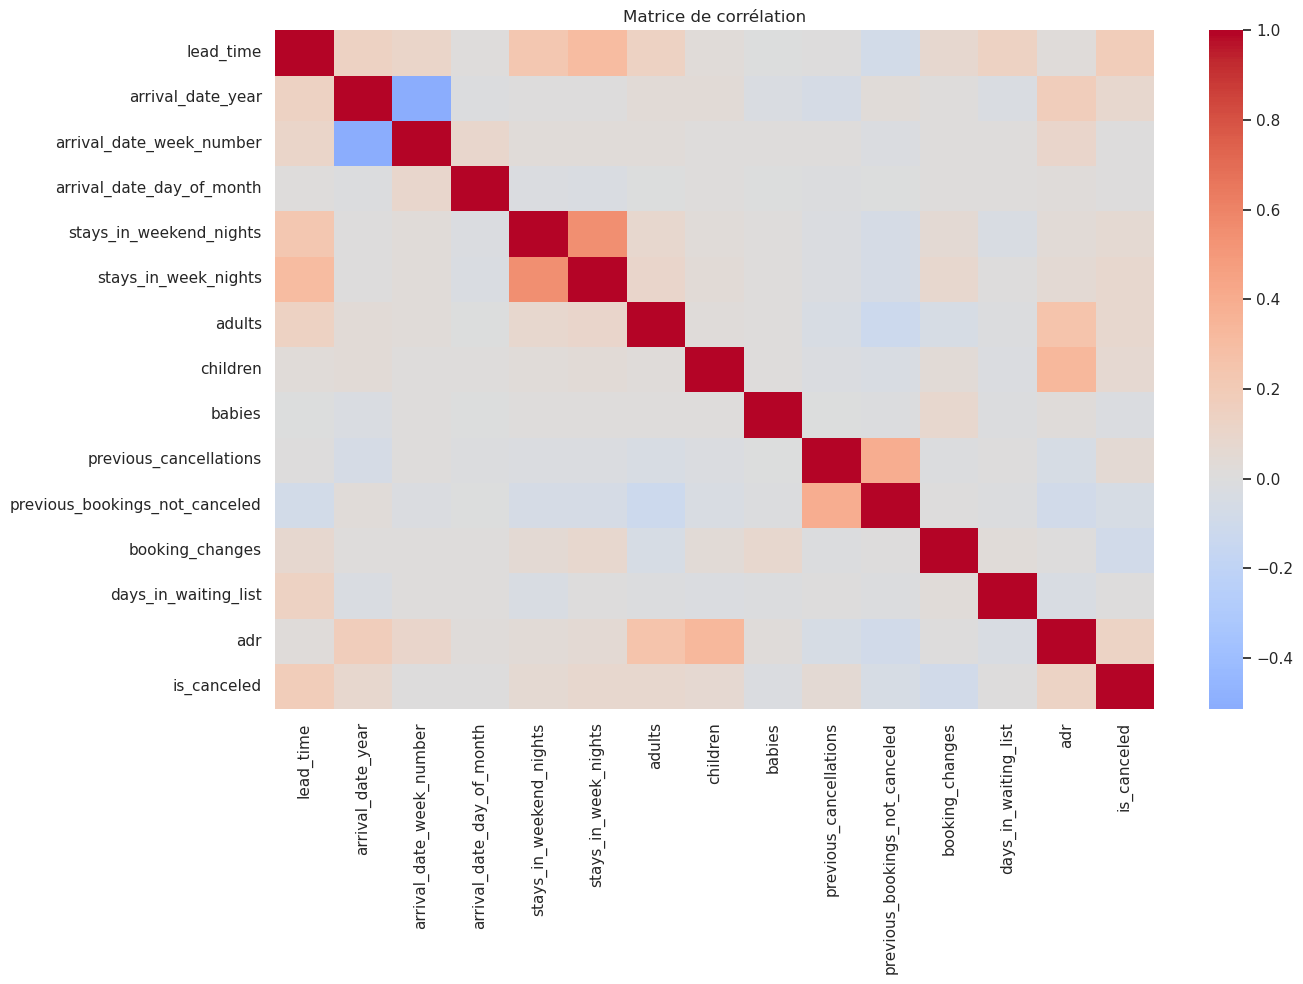

In [55]:
# CORRÉLATIONS

numeric_columns = [
    "lead_time",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "is_canceled"
]

correlation = hotel[numeric_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(correlation, annot=False,cmap="coolwarm",center=0)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png",dpi=300)
plt.show()

# 27. **Export du dataset nettoyé**

In [53]:
# EXPORT DATASET NETTOYÉ
cleaned_path = (CLEANED_DIR /"hotel_bookings_cleaned.csv")
hotel.to_csv(cleaned_path,index=False)
print(f"Dataset nettoyé sauvegardé : {cleaned_path}")

Dataset nettoyé sauvegardé : ../outputs/cleaned/hotel_bookings_cleaned.csv


## 28. **Dataset spécial pour Superset**

In [54]:
# DATASET POUR SUPERSET

superset_columns = [
    "hotel",
    "arrival_date",
    "arrival_year",
    "arrival_month_num",
    "arrival_date_month",
    "lead_time",
    "lead_time_category",
    "total_guests",
    "total_nights",
    "is_cancelled",
    "adr",
    "estimated_revenue",
    "market_segment",
    "distribution_channel",
    "customer_type",
    "meal",
    "country",
    "deposit_type",
    "reservation_status"
]

superset_df = hotel[superset_columns].copy()
superset_df.to_csv(CLEANED_DIR / "hotel_bookings_superset.csv",index=False)
display(superset_df.head())

,hotel,arrival_date,arrival_year,arrival_month_num,arrival_date_month,lead_time,lead_time_category,total_guests,total_nights,is_cancelled,adr,estimated_revenue,market_segment,distribution_channel,customer_type,meal,country,deposit_type,reservation_status
0,Resort Hotel,2015-07-01,2015,7,July,342,>90 days,2.0,0,False,0.0,0.0,Direct,Direct,Transient,BB,PRT,No Deposit,Check-Out
1,Resort Hotel,2015-07-01,2015,7,July,737,>90 days,2.0,0,False,0.0,0.0,Direct,Direct,Transient,BB,PRT,No Deposit,Check-Out
2,Resort Hotel,2015-07-01,2015,7,July,7,0-30 days,1.0,1,False,75.0,75.0,Direct,Direct,Transient,BB,GBR,No Deposit,Check-Out
3,Resort Hotel,2015-07-01,2015,7,July,13,0-30 days,1.0,1,False,75.0,75.0,Corporate,Corporate,Transient,BB,GBR,No Deposit,Check-Out
4,Resort Hotel,2015-07-01,2015,7,July,14,0-30 days,2.0,2,False,98.0,196.0,Online TA,TA/TO,Transient,BB,GBR,No Deposit,Check-Out
